/Mag6PlusEarthquakes_1900-2013 (1).csv


Saving Mag6PlusEarthquakes_1900-2013 (1).csv to Mag6PlusEarthquakes_1900-2013 (1).csv

File 'Mag6PlusEarthquakes_1900-2013 (1).csv' uploaded successfully!

Dataset loaded: 8313 rows

--- Column Names ---
['time', 'Date', 'Time', 'Unnamed: 3', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type']

✓ All required columns found

--- Missing Values Summary ---
time             0
Date             0
Time             0
Unnamed: 3    8313
latitude         0
longitude        0
depth            0
mag              1
magType         15
nst            202
gap           7215
dmin          8149
rms           7149
net              0
id               0
updated          0
place            9
type             0
dtype: int64

--- Converting magnitude and depth to numeric ---
Conversion complete

Dropped 1 rows with missing magnitude or depth
Remaining rows: 8312


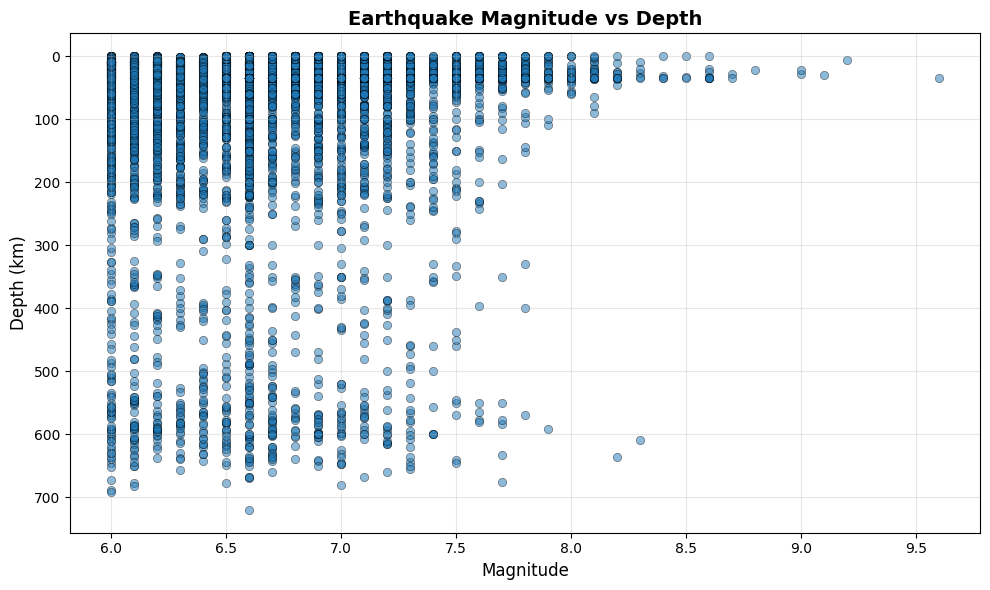


--- Creating magnitude categories ---
mag_category
<4        0
4-5       0
5-6       0
6+     8312
Name: count, dtype: int64


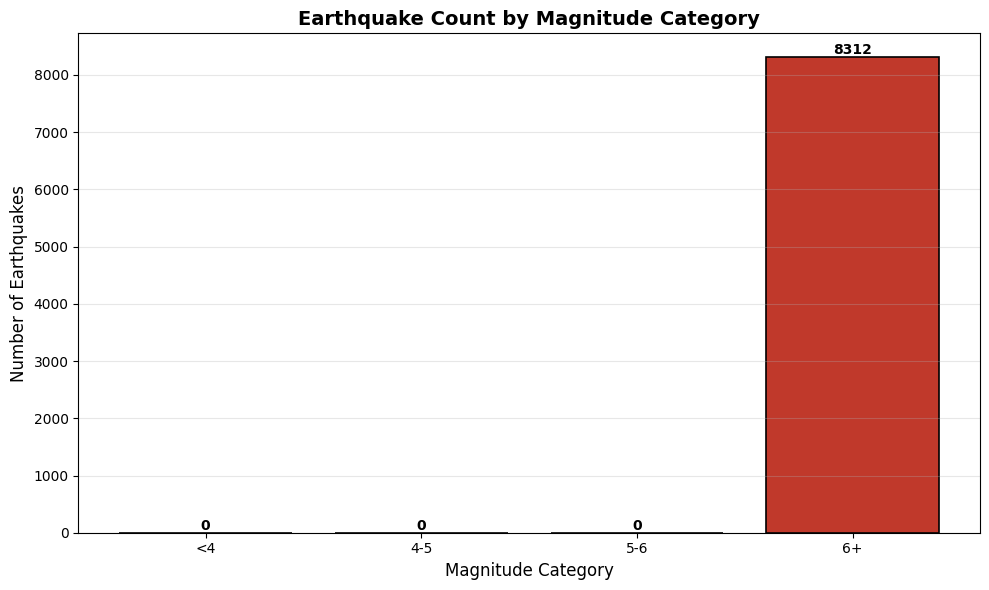


--- Summary Statistics ---
Total earthquakes analyzed: 8312
Magnitude range: 6.00 to 9.60
Depth range: 0.00 to 720.00 km
Average magnitude: 6.56
Average depth: 76.85 km


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload CSV file from local machine
print("/Mag6PlusEarthquakes_1900-2013 (1).csv")
uploaded = files.upload()
# I understand that this allows me to manually upload a file into Colab.
# Without AI, I would not have known how to handle file uploads in this environment.


# Get the filename (assuming one file uploaded)
filename = list(uploaded.keys())[0]
print(f"\nFile '{filename}' uploaded successfully!\n")

# Step 2: Load CSV into pandas DataFrame
df = pd.read_csv(filename)
print(f"Dataset loaded: {len(df)} rows")
# I understand this reads the CSV into a pandas DataFrame.
# I am comfortable with this step from other courses, but it has been a while.

# Step 3: Display column names
print("\n--- Column Names ---")
print(df.columns.tolist())

# Step 4: Check for required columns
required_columns = ['mag', 'depth']
missing_columns = [col for col in required_columns if col not in df.columns]
# I understand the logic here: this checks whether the dataset contains
# the columns needed for the visualization.
# I would not have thought to add this check on my own.

if missing_columns:
    print(f"\nERROR: Missing required columns: {missing_columns}")
    print("Available columns:", df.columns.tolist())
else:
    print("\n✓ All required columns found")

# Step 5: Display missing value summary
print("\n--- Missing Values Summary ---")
print(df.isnull().sum())

# Step 6: Convert magnitude and depth to numeric (handle errors)
print("\n--- Converting magnitude and depth to numeric ---")
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
print("Conversion complete")
# I understand that this converts the magnitude column to numeric values.
# I did not fully understand what errors='coerce' does.
# but I learned that it forces invalid values to NaN so they can be handled accordingly.

# Step 7: Drop rows where magnitude or depth is missing
rows_before = len(df)
df = df.dropna(subset=['mag', 'depth'])
rows_after = len(df)
print(f"\nDropped {rows_before - rows_after} rows with missing magnitude or depth")
print(f"Remaining rows: {rows_after}")
# I understand that this removes rows missing magnitude or depth.
# I see why this is important for visualization accuracy,
# since plotting missing values would break the chart.

# Check if we have data left to visualize
if len(df) == 0:
    print("\nERROR: No valid data remaining after cleaning!")
else:
    # Step 8: Create scatter plot - Magnitude vs Depth
    plt.figure(figsize=(10, 6))
    plt.scatter(df['mag'], df['depth'], alpha=0.5, edgecolors='k', linewidth=0.5)
    plt.xlabel('Magnitude', fontsize=12)
    plt.ylabel('Depth (km)', fontsize=12)
    plt.title('Earthquake Magnitude vs Depth', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()  # Invert y-axis so deeper earthquakes appear lower
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # I understand the basic idea of plotting magnitude vs depth.
# However, I would not have known to invert the y-axis without AI,
# even though it makes more sense for depth.

    # Step 9: Create magnitude categories
    print("\n--- Creating magnitude categories ---")

    # Define bins and labels for magnitude categories
    bins = [0, 4, 5, 6, float('inf')]
    labels = ['<4', '4-5', '5-6', '6+']
        # I initially accepted the default magnitude bins (<4, 4–5, 5–6, 6+),
# but after testing the output I realized my dataset already only includes 6+ earthquakes.
# This required a refinement prompt to create more meaningful bins.

    # Create category column
    df['mag_category'] = pd.cut(df['mag'], bins=bins, labels=labels, right=False)
    # I understand that pd.cut() groups continuous values into labeled ranges.
# I would not have written this from scratch without AI,
# but I understand how the bins define magnitude intervals.

    # Count earthquakes in each category
    category_counts = df['mag_category'].value_counts().sort_index()
    print(category_counts)

    # Step 10: Create bar chart of earthquake counts by category
    plt.figure(figsize=(10, 6))
    bars = plt.bar(category_counts.index, category_counts.values,
                    color=['#2ecc71', '#f39c12', '#e74c3c', '#c0392b'],
                    edgecolor='black', linewidth=1.2)

    plt.xlabel('Magnitude Category', fontsize=12)
    plt.ylabel('Number of Earthquakes', fontsize=12)
    plt.title('Earthquake Count by Magnitude Category', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Step 11: Display basic statistics
    print("\n--- Summary Statistics ---")
    print(f"Total earthquakes analyzed: {len(df)}")
    print(f"Magnitude range: {df['mag'].min():.2f} to {df['mag'].max():.2f}")
    print(f"Depth range: {df['depth'].min():.2f} to {df['depth'].max():.2f} km")
    print(f"Average magnitude: {df['mag'].mean():.2f}")
    print(f"Average depth: {df['depth'].mean():.2f} km")

    # Reflection:
# I am comfortable reading and modifying this code,
# but I would not have built this full workflow independently yet.
# AI significantly accelerated setup and structure,
# while I focused on interpreting the results and refining the visualization.

Please select your earthquake CSV file to upload...


Saving Mag6PlusEarthquakes_1900-2013 (1).csv to Mag6PlusEarthquakes_1900-2013 (1) (1).csv

File 'Mag6PlusEarthquakes_1900-2013 (1) (1).csv' uploaded successfully!

Dataset loaded: 8313 rows

--- Column Names ---
['time', 'Date', 'Time', 'Unnamed: 3', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type']

✓ All required columns found

--- Missing Values Summary ---
time             0
Date             0
Time             0
Unnamed: 3    8313
latitude         0
longitude        0
depth            0
mag              1
magType         15
nst            202
gap           7215
dmin          8149
rms           7149
net              0
id               0
updated          0
place            9
type             0
dtype: int64

--- Converting magnitude and depth to numeric ---
Conversion complete

Dropped 1 rows with missing magnitude or depth
Remaining rows: 8312


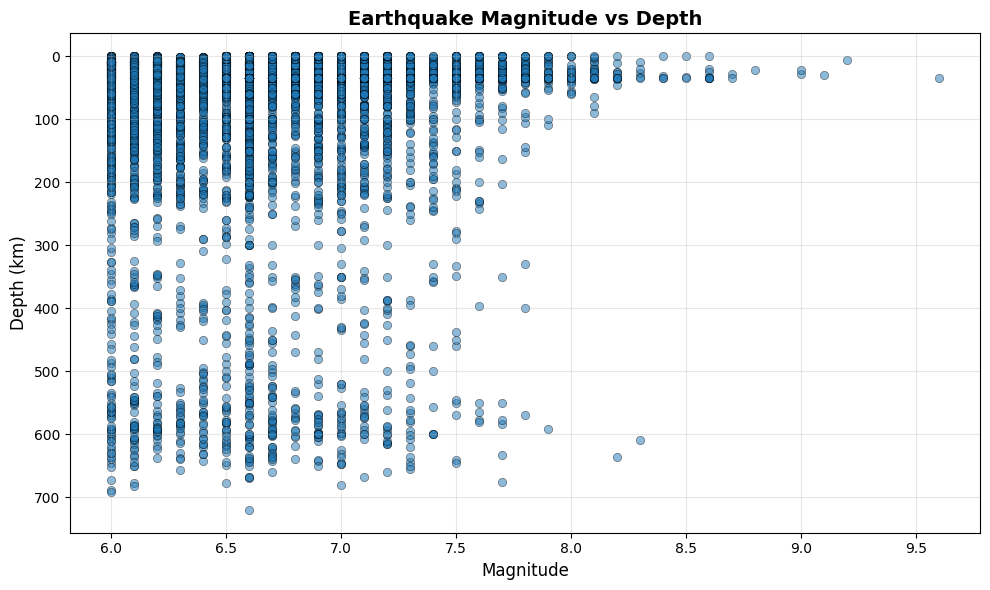


--- Creating magnitude categories for 6+ earthquakes ---
mag_category
6.0-6.5    3827
6.5-7.0    2708
7.0-7.5    1319
7.5-8.0     372
8.0+         86
Name: count, dtype: int64


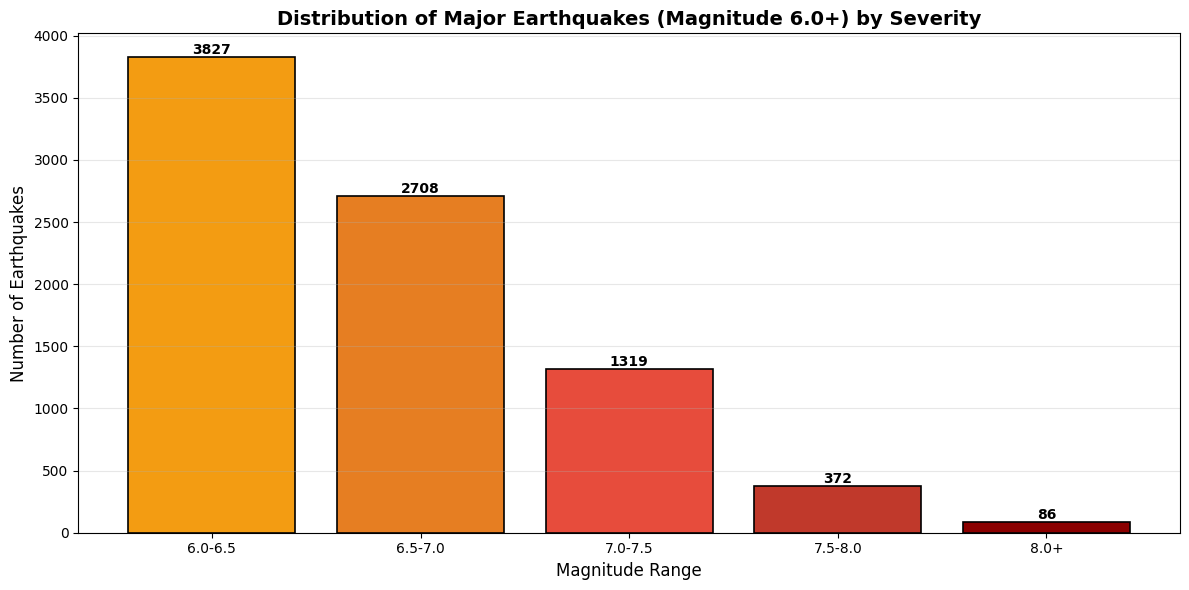


--- Summary Statistics ---
Total earthquakes analyzed: 8312
Magnitude range: 6.00 to 9.60
Depth range: 0.00 to 720.00 km
Average magnitude: 6.56
Average depth: 76.85 km

Most common magnitude range: 6.0-6.5
Number of magnitude 8.0+ earthquakes: 86


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 1: Upload CSV file from local machine
print("Please select your earthquake CSV file to upload...")
uploaded = files.upload()

# Get the filename (assuming one file uploaded)
filename = list(uploaded.keys())[0]
print(f"\nFile '{filename}' uploaded successfully!\n")

# Step 2: Load CSV into pandas DataFrame
df = pd.read_csv(filename)
print(f"Dataset loaded: {len(df)} rows")

# Step 3: Display column names
print("\n--- Column Names ---")
print(df.columns.tolist())

# Step 4: Check for required columns
required_columns = ['mag', 'depth']
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"\nERROR: Missing required columns: {missing_columns}")
    print("Available columns:", df.columns.tolist())
else:
    print("\n✓ All required columns found")

# Step 5: Display missing value summary
print("\n--- Missing Values Summary ---")
print(df.isnull().sum())

# Step 6: Convert magnitude and depth to numeric (handle errors)
print("\n--- Converting magnitude and depth to numeric ---")
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
print("Conversion complete")

# Step 7: Drop rows where magnitude or depth is missing
rows_before = len(df)
df = df.dropna(subset=['mag', 'depth'])
rows_after = len(df)
print(f"\nDropped {rows_before - rows_after} rows with missing magnitude or depth")
print(f"Remaining rows: {rows_after}")

# Check if we have data left to visualize
if len(df) == 0:
    print("\nERROR: No valid data remaining after cleaning!")
else:
    # Step 8: Create scatter plot - Magnitude vs Depth
    plt.figure(figsize=(10, 6))
    plt.scatter(df['mag'], df['depth'], alpha=0.5, edgecolors='k', linewidth=0.5)
    plt.xlabel('Magnitude', fontsize=12)
    plt.ylabel('Depth (km)', fontsize=12)
    plt.title('Earthquake Magnitude vs Depth', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()  # Invert y-axis so deeper earthquakes appear lower
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Step 9: Create magnitude categories for 6+ dataset
    print("\n--- Creating magnitude categories for 6+ earthquakes ---")

    # Define bins for magnitude 6.0 and above
    # These bins are chosen to capture meaningful seismic categories:
    # 6.0-6.5: Strong earthquakes (can cause damage in populated areas)
    # 6.5-7.0: Major earthquakes (serious damage over larger areas)
    # 7.0-7.5: Major to Great earthquakes (widespread serious damage)
    # 7.5-8.0: Great earthquakes (serious damage over large regions)
    # 8.0+: Great earthquakes (can cause massive destruction, rare events)
    bins = [6.0, 6.5, 7.0, 7.5, 8.0, float('inf')]
    labels = ['6.0-6.5', '6.5-7.0', '7.0-7.5', '7.5-8.0', '8.0+']



    # Create category column
    df['mag_category'] = pd.cut(df['mag'], bins=bins, labels=labels, right=False)

    # Count earthquakes in each category
    category_counts = df['mag_category'].value_counts().sort_index()
    print(category_counts)

    # Step 10: Create bar chart of earthquake counts by category
    plt.figure(figsize=(12, 6))

    # Color gradient from yellow (moderate) to dark red (extreme)
    # Reflects increasing severity and rarity of earthquakes
    colors = ['#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8b0000']

    bars = plt.bar(category_counts.index, category_counts.values,
                    color=colors,
                    edgecolor='black', linewidth=1.2)

    plt.xlabel('Magnitude Range', fontsize=12)
    plt.ylabel('Number of Earthquakes', fontsize=12)
    plt.title('Distribution of Major Earthquakes (Magnitude 6.0+) by Severity',
              fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Step 11: Display basic statistics
    print("\n--- Summary Statistics ---")
    print(f"Total earthquakes analyzed: {len(df)}")
    print(f"Magnitude range: {df['mag'].min():.2f} to {df['mag'].max():.2f}")
    print(f"Depth range: {df['depth'].min():.2f} to {df['depth'].max():.2f} km")
    print(f"Average magnitude: {df['mag'].mean():.2f}")
    print(f"Average depth: {df['depth'].mean():.2f} km")

    # Additional statistics relevant to major earthquakes
    print(f"\nMost common magnitude range: {category_counts.idxmax()}")
    print(f"Number of magnitude 8.0+ earthquakes: {len(df[df['mag'] >= 8.0])}")